In [1]:
import pandas as pd
import numpy as np
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.stats.diagnostic import het_arch

In [2]:
def wrangle(filename):
    # load data
    df = pd.read_csv(filename)
    # drop rows and columns
    df = df.dropna()
    df = df.drop(0)
    df = df.drop(columns="Volume")
    df = df.reset_index(drop=True)
    # rename column
    df = df.rename(columns={"Price": "Date"})
    # change data types
    df["Date"] = pd.DatetimeIndex(df["Date"])  # date
    cols = ["Open", "High", "Low", "Close"]
    df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
    pd.set_option("display.precision", 14)
    df = df.set_index("Date")
    df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
    df = df.dropna()
    return df

In [3]:
df = wrangle("EURUSD_data.csv")
df

,Close,High,Low,Open,log_returns
Date,,,,,
2015-01-02,1.20894134044647,1.20895600318909,1.20107996463776,1.20886826515198,-0.07619367162766
2015-01-05,1.19464325904846,1.19759047031403,1.18890941143036,1.19550013542175,-1.18974385651027
2015-01-06,1.19390153884888,1.19699990749359,1.18869316577911,1.19383025169373,-0.06210645277236
2015-01-07,1.18753564357758,1.19000017642975,1.18040060997009,1.18747925758362,-0.53462761740070
2015-01-08,1.18360006809235,1.18480598926544,1.17560064792633,1.18389427661896,-0.33195730466939
...,...,...,...,...,...
2026-04-06,1.15099966526031,1.15700566768646,1.15069496631622,1.15118515491486,-0.27546916133570
2026-04-07,1.15412127971649,1.15834581851959,1.15252518653870,1.15405476093292,0.27084187241492
2026-04-08,1.16866123676300,1.17233300209045,1.16668415069580,1.16904366016388,1.25195939432197



MODEL COMPARISON

                   Model                                         Parameters  \
0         Standard GARCH  [0.0018132732870281985, 0.036569158364127774, ...   
1  Modified Log-Δt GARCH  [0.0019243141371294095, 0.03687853786812315, 0...   
2                 IGARCH       [0.0007108591552678354, 0.04092530282421656]   
3                 EGARCH  [-0.009808204524634663, 0.08670391102510747, 0...   

                   AIC                  BIC  
0  3905.53447966140129  3923.48582286833380  
1  3906.31896322799366  3924.27030643492617  
2  3911.49459734484026  3923.46215948279496  
3  3907.57217974910600  3931.50730402501586  

STATIONARITY / PERSISTENCE CHECK

Standard GARCH   : α + β = 0.992779
Modified GARCH   : α + β = 0.992751
IGARCH           : α + β = 1.000000 
EGARCH           :  β = 0.991444
Modified GARCH   : (np.float64(0.0018132732870281985), np.float64(0.03687853786812315), np.float64(0.9558729498415145))


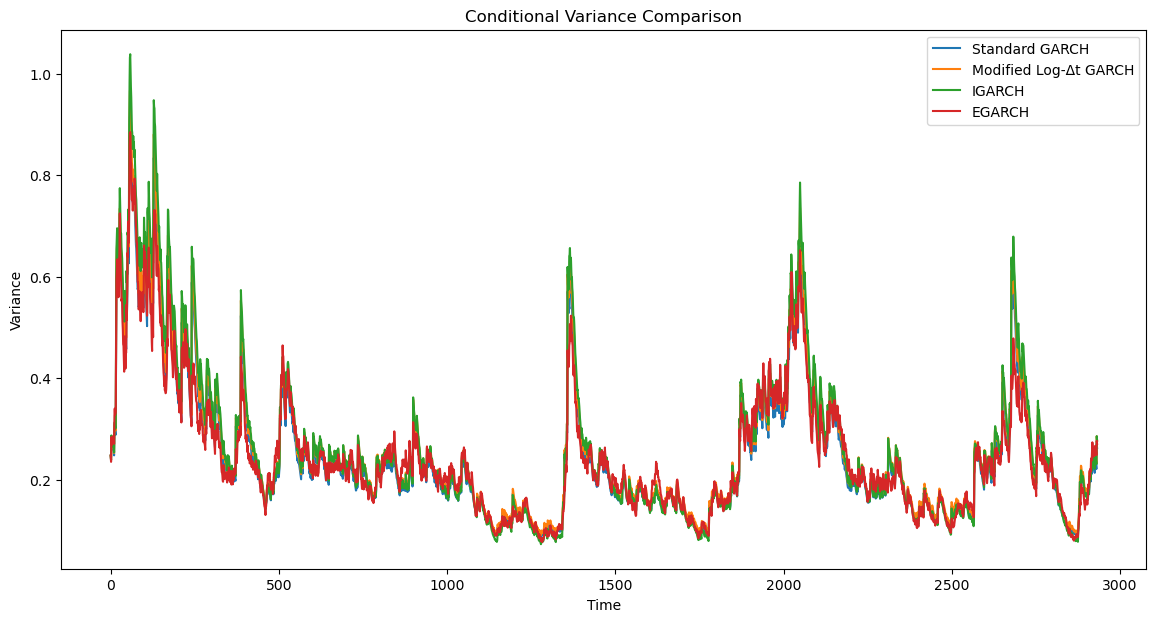

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize


# PREPARE DATA


df = df.dropna().copy()

r = df["log_returns"].values
n = len(r)
dt = 0.95
dt_log = np.full(n,dt)


# STANDARD GARCH(1,1)

def standard_garch(params, r):

    omega, alpha, beta = params

    sigma2 = np.zeros(len(r))

    sigma2[0] = np.var(r)

    for t in range(1, len(r)):

        sigma2[t] = (
            omega
            + alpha * (r[t-1]**2)
            + beta * sigma2[t-1]
        )

    return sigma2



# MODIFIED LOG-Δt GARCH
# σ²_t = ω + α(r²_(t-1)/Δt_t) + βσ²_(t-1)

def modified_log_garch(params, r, dt):

    omega, alpha, beta = params

    sigma2 = np.zeros(len(r))

    sigma2[0] = np.var(r)

    for t in range(1, len(r)):

        sigma2[t] = (
            omega
            + alpha * ((r[t-1]**2) / dt[t-1])
            + beta * sigma2[t-1]
        )

    return sigma2



# IGARCH
# α + β = 1
def igarch(params, r):

    omega, alpha = params

    beta = 1 - alpha

    sigma2 = np.zeros(len(r))

    sigma2[0] = np.var(r)

    for t in range(1, len(r)):

        sigma2[t] = (
            omega
            + alpha * (r[t-1]**2)
            + beta * sigma2[t-1]
        )

    return sigma2



# EGARCH
def egarch(params, r):
    omega, alpha, beta, gamma = params

    sigma2 = np.zeros(len(r))
    log_sigma2 = np.zeros(len(r))

    sigma2[0] = np.var(r) + 1e-8
    log_sigma2[0] = np.log(sigma2[0])

    for t in range(1, len(r)):

        z = r[t-1] / np.sqrt(sigma2[t-1] + 1e-12)

        log_sigma2[t] = (
            omega
            + beta * log_sigma2[t-1]
            + alpha * (np.abs(z) - np.sqrt(2/np.pi))
            + gamma * z
        )

        # 🔥 CRITICAL STABILITY CLIP
        log_sigma2[t] = np.clip(log_sigma2[t], -20, 20)

        sigma2[t] = np.exp(log_sigma2[t])

    return sigma2



# NEGATIVE LOG-LIKELIHOODS
def neg_loglik_standard(params, r):

    sigma2 = standard_garch(params, r)

    sigma2 = np.maximum(sigma2, 1e-8)

    ll = -0.5 * np.sum(
        np.log(2*np.pi)
        + np.log(sigma2)
        + (r**2 / sigma2)
    )

    return -ll


def neg_loglik_modified(params, r, dt):

    sigma2 = modified_log_garch(params, r, dt)

    sigma2 = np.maximum(sigma2, 1e-8)

    ll = -0.5 * np.sum(
        np.log(2*np.pi)
        + np.log(dt*sigma2)
        + (r**2 / (dt*sigma2))
    )

    return -ll


def neg_loglik_igarch(params, r):

    sigma2 = igarch(params, r)

    sigma2 = np.maximum(sigma2, 1e-8)

    ll = -0.5 * np.sum(
        np.log(2*np.pi)
        + np.log(sigma2)
        + (r**2 / sigma2)
    )

    return -ll


def neg_loglik_egarch(params, r):

    sigma2 = egarch(params, r)

    sigma2 = np.maximum(sigma2, 1e-8)

    ll = -0.5 * np.sum(
        np.log(2*np.pi)
        + np.log(sigma2)
        + (r**2 / sigma2)
    )

    return -ll



# PARAMETER ESTIMATION

# Standard GARCH
result_std = minimize(
    neg_loglik_standard,
    x0=[0.00001, 0.05, 0.90],
    args=(r,),
    method='L-BFGS-B',
    bounds=[
        (1e-8, None),
        (1e-8, 1),
        (1e-8, 1)
    ]
)

params_std = result_std.x


#  Modified Log-Δt GARCH
result_mod = minimize(
    neg_loglik_modified,
    x0=[0.00001, 0.05, 0.90],
    args=(r, dt_log),
    method='L-BFGS-B',
    bounds=[
        (1e-8, None),
        (1e-8, 1),
        (1e-8, 1)
    ]
)

params_mod = result_mod.x


# - IGARCH
result_igarch = minimize(
    neg_loglik_igarch,
    x0=[0.00001, 0.05],
    args=(r,),
    method='L-BFGS-B',
    bounds=[
        (1e-8, None),
        (1e-8, 1)
    ]
)

params_igarch = result_igarch.x


# ---------- EGARCH
result_egarch = minimize(
    neg_loglik_egarch,
    x0=[-0.1, 0.10, 0.90, -0.05],
    args=(r,),
    method='L-BFGS-B'
)

params_egarch = result_egarch.x



# COMPUTE CONDITIONAL VARIANCES
sigma_std = standard_garch(
    params_std,
    r
)

sigma_mod = modified_log_garch(
    params_mod,
    r,
    dt_log
)

sigma_igarch = igarch(
    params_igarch,
    r
)

sigma_egarch = egarch(
    params_egarch,
    r
)



# AIC / BIC
def aic_bic(loglik, k, n):

    aic = 2*k - 2*loglik

    bic = k*np.log(n) - 2*loglik

    return aic, bic


# LOG-LIKELIHOODS
ll_std = -result_std.fun

ll_mod = -result_mod.fun

ll_igarch = -result_igarch.fun

ll_egarch = -result_egarch.fun



# INFORMATION CRITERIA
aic_std, bic_std = aic_bic(ll_std, 3, n)

aic_mod, bic_mod = aic_bic(ll_mod, 3, n)

aic_igarch, bic_igarch = aic_bic(ll_igarch, 2, n)

aic_egarch, bic_egarch = aic_bic(ll_egarch, 4, n)


# RESULTS TABLE
results = pd.DataFrame({

    "Model": [
        "Standard GARCH",
        "Modified Log-Δt GARCH",
        "IGARCH",
        "EGARCH"
    ],

    "Parameters": [
        params_std,
        params_mod,
        params_igarch,
        params_egarch
    ],

    "AIC": [
        aic_std,
        aic_mod,
        aic_igarch,
        aic_egarch
    ],

    "BIC": [
        bic_std,
        bic_mod,
        bic_igarch,
        bic_egarch
    ]
})

print("\nMODEL COMPARISON\n")

print(results)


# STATIONARITY / PERSISTENCE CHECK
omega_s, alpha_s, beta_s = params_std
omega_m, alpha_m, beta_m = params_mod

omega_i, alpha_i = params_igarch
beta_i = 1 - alpha_i

omega_e, alpha_e, beta_e, gamma_e = params_egarch

print("\nSTATIONARITY / PERSISTENCE CHECK\n")

print(f"Standard GARCH   : α + β = {alpha_s + beta_s:.6f}")

print(f"Modified GARCH   : α + β = {alpha_m + beta_m:.6f}")

print(f"IGARCH           : α + β = {alpha_i + beta_i:.6f} ")

print(f"EGARCH           :  β = {beta_e:.6f}")

print(f"Modified GARCH   : {omega_s, alpha_m , beta_m}")



# PLOT VOLATILITIES
plt.figure(figsize=(14,7))

plt.plot(
    sigma_std,
    label="Standard GARCH"
)

plt.plot(
    sigma_mod,
    label="Modified Log-Δt GARCH"
)

plt.plot(
    sigma_igarch,
    label="IGARCH"
)

plt.plot(
    sigma_egarch,
    label="EGARCH"
)

plt.title("Conditional Variance Comparison")

plt.xlabel("Time")

plt.ylabel("Variance")

plt.legend()

plt.show()

In [308]:
# PART 2 — LOSS FUNCTIONS & 3-STEP-AHEAD FORECAST
# USING PART 1 PARAMETERS DIRECTLY

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from itertools import combinations


# 80/20 SPLIT
r_full    = df.log_returns.values
n_full    = len(r_full)
test_size = int(n_full * 0.2)
split     = n_full - test_size

r_train   = r_full[:split]
r_test    = r_full[split:]
n_train   = len(r_train)

test_index   = df.log_returns.tail(test_size).index
test_returns = df.log_returns.tail(test_size)

print(f"Train size: {n_train}  |  Test size: {test_size}")


# CONSTANT LOGARITHMIC TIME STEP FOR TRAINING SET
dt_train = np.full(n_train,dt)


# REUSE PART 1 PARAMETERS DIRECTLY
p_std = params_std
p_mod = params_mod
p_ig  = params_igarch
p_eg  = params_egarch


# ROLLING FORECAST FUNCTIONS
def roll_forecast_std(params, r_train, r_test):
    omega, alpha, beta = params
    s2 = standard_garch(params, r_train)[-1]
    preds = []
    for rt in r_test:
        s2 = omega + alpha * rt**2 + beta * s2
        preds.append(s2)
    return np.array(preds)


def roll_forecast_mod(params, r_train, r_test, dt_train):
    omega, alpha, beta = params
    s2 = modified_log_garch(params, r_train, dt_train)[-1]
    dt_t = dt
    preds = []
    for rt in r_test:
        s2 = omega + alpha * (rt**2 / dt_t) + beta * s2
        preds.append(s2)
    return np.array(preds)


def roll_forecast_ig(params, r_train, r_test):
    omega, alpha = params
    beta = 1 - alpha
    s2   = igarch(params, r_train)[-1]
    preds = []
    for rt in r_test:
        s2 = omega + alpha * rt**2 + beta * s2
        preds.append(s2)
    return np.array(preds)


def roll_forecast_eg(params, r_train, r_test):
    omega, alpha, beta, gamma = params
    s2     = egarch(params, r_train)[-1]
    log_s2 = np.log(max(s2, 1e-8))
    preds  = []
    for rt in r_test:
        z      = rt / np.sqrt(max(s2, 1e-8))
        log_s2 = np.clip(
            omega
            + beta  * log_s2
            + alpha * (np.abs(z) - np.sqrt(2/np.pi))
            + gamma * z,
            -50, 50
        )
        s2 = np.exp(log_s2)
        preds.append(s2)
    return np.array(preds)

# OUT-OF-SAMPLE FORECASTS
y_test_std = pd.Series(
    roll_forecast_std(p_std, r_train, r_test),
    index=test_index
)
y_test_mod = pd.Series(
    roll_forecast_mod(p_mod, r_train, r_test, dt_train),
    index=test_index
)
y_test_igarch = pd.Series(
    roll_forecast_ig(p_ig, r_train, r_test),
    index=test_index
)
y_test_egarch = pd.Series(
    roll_forecast_eg(p_eg, r_train, r_test),
    index=test_index
)

print("y_test_std shape:",    y_test_std.shape)
print("y_test_mod shape:",    y_test_mod.shape)
print("y_test_igarch shape:", y_test_igarch.shape)
print("y_test_egarch shape:", y_test_egarch.shape)


# SHARED
actual      = r_test**2
r_test_vals = r_test

model_names = [
    "Standard GARCH",
    "Modified Log-Δt GARCH",
    "IGARCH",
    "EGARCH"
]

preds_list = [
    y_test_std.values,
    y_test_mod.values,
    y_test_igarch.values,
    y_test_egarch.values
]


# LOSS FUNCTIONS
def mse(actual, pred):
    pred = np.maximum(pred, 1e-8)
    return np.mean((actual - pred)**2)


def mae(actual, pred):
    pred = np.maximum(pred, 1e-8)
    return np.mean(np.abs(actual - pred))


def msre(actual, pred):
    actual = np.maximum(actual, 1e-8)
    pred   = np.maximum(pred,   1e-8)
    return np.mean(((actual - pred) / actual)**2)


def qlike(actual, pred):
    actual = np.maximum(actual, 1e-8)
    pred   = np.maximum(pred,   1e-8)
    return np.mean(np.log(pred) + actual / pred)



# LOSS TABLE
loss_df = pd.DataFrame({
    "Model": model_names,
    "MSE":   [mse(actual,  p) for p in preds_list],
    "MAE":   [mae(actual,  p) for p in preds_list],
    "MSRE":  [msre(actual, p) for p in preds_list],
    "QLIKE": [qlike(actual, p) for p in preds_list]
})

loss_df[["MSE","MAE","MSRE","QLIKE"]] = loss_df[
    ["MSE","MAE","MSRE","QLIKE"]
].round(8)

print("\nOUT-OF-SAMPLE LOSS FUNCTIONS\n")
print(loss_df.to_string(index=False))



# MULTI-STEP GARCH FORECAST FUNCTION
def garch_forecast(omega, alpha, beta, sigma2_last, h=3):
    forecasts    = np.zeros(h)
    forecasts[0] = omega + (alpha + beta) * sigma2_last
    for step in range(1, h):
        forecasts[step] = omega + (alpha + beta) * forecasts[step-1]
    return forecasts



# LAST CONDITIONAL VARIANCES FROM FULL TRAINING SET


sv_s = standard_garch(p_std, r_train)[-1]
sv_m = modified_log_garch(p_mod, r_train, dt_train)[-1]
sv_i = igarch(p_ig, r_train)[-1]
sv_e = egarch(p_eg, r_train)[-1]



# 3-STEP FORECASTS
fc_std = garch_forecast(
    p_std[0], p_std[1], p_std[2],
    sv_s, h=3
)

fc_mod = garch_forecast(
    p_mod[0], p_mod[1], p_mod[2],
    sv_m, h=3
)

fc_igarch = garch_forecast(
    p_ig[0], p_ig[1], 1 - p_ig[1],
    sv_i, h=3
)

# ---------- EGARCH multi-step
fc_egarch  = np.zeros(3)
log_sv_e   = np.log(np.maximum(sv_e, 1e-8))

for h in range(3):
    log_sv_e   = p_eg[0] + p_eg[2] * log_sv_e
    fc_egarch[h] = np.exp(log_sv_e)



# FORECAST TABLE
forecast_df = pd.DataFrame({
    "Horizon":             [1, 2, 3],
    "Std GARCH σ²":        fc_std.round(8),
    "Modified Log-Δt σ²":  fc_mod.round(8),
    "IGARCH σ²":           fc_igarch.round(8),
    "EGARCH σ²":           fc_egarch.round(8)
})

print("\n3-STEP-AHEAD VARIANCE FORECASTS\n")
print(forecast_df.to_string(index=False))

Train size: 2347  |  Test size: 586
y_test_std shape: (586,)
y_test_mod shape: (586,)
y_test_igarch shape: (586,)
y_test_egarch shape: (586,)

OUT-OF-SAMPLE LOSS FUNCTIONS

                Model        MSE        MAE                 MSRE       QLIKE
       Standard GARCH 0.19623445 0.20875798 9.50747611481677e+11 -0.80420007
Modified Log-Δt GARCH 0.20521929 0.18486033 4.22095053446137e+11 -0.76725317
               IGARCH 0.19566065 0.21226654 9.74158992917654e+11 -0.80729497
               EGARCH 0.20093362 0.20541677 9.48973732396869e+11 -0.78664261

3-STEP-AHEAD VARIANCE FORECASTS

 Horizon  Std GARCH σ²  Modified Log-Δt σ²  IGARCH σ²  EGARCH σ²
       1    0.23074812          0.15238181 0.24333788 0.23630976
       2    0.23089527          0.15244913 0.24404874 0.23690945
       3    0.23104136          0.15251597 0.24475960 0.23750550



3-STEP-AHEAD VARIANCE FORECASTS

 Horizon  Std GARCH σ²  Modified Log-Δt σ²  IGARCH σ²  EGARCH σ²
       1    0.23074812          0.15238181 0.24333788 0.23630976
       2    0.23089527          0.15244913 0.24404874 0.23690945
       3    0.23104136          0.15251597 0.24475960 0.23750550

ACTUAL vs FORECASTED VOLATILITY (σ)

 Horizon  Actual |r| (proxy)  Actual Var (r²) proxy  Std GARCH σ  Modified Log-Δt σ   IGARCH σ   EGARCH σ
       1          0.17937674             0.03217602   0.48036248         0.39036113 0.49329290 0.48611702
       2          0.04706370             0.00221499   0.48051563         0.39044735 0.49401290 0.48673344
       3          0.08647517             0.00747795   0.48066762         0.39053293 0.49473185 0.48734536


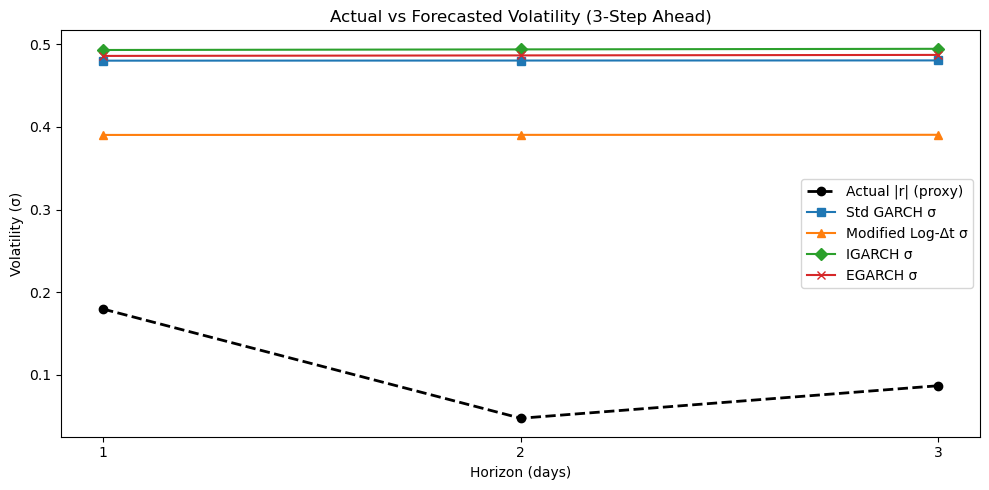


FORECAST ERROR  (Actual |r| − Forecasted σ)

 Horizon  Std GARCH error  Modified Δt error  IGARCH error  EGARCH error
       1      -0.30098574        -0.21098439   -0.31391616   -0.30674028
       2      -0.43345193        -0.34338365   -0.44694920   -0.43966974
       3      -0.39419245        -0.30405776   -0.40825668   -0.40087020


In [316]:
# FORECAST TABLE

forecast_df = pd.DataFrame({
    "Horizon":             [1, 2, 3],
    "Std GARCH σ²":        fc_std.round(8),
    "Modified Log-Δt σ²":  fc_mod.round(8),
    "IGARCH σ²":           fc_igarch.round(8),
    "EGARCH σ²":           fc_egarch.round(8)
})

print("\n3-STEP-AHEAD VARIANCE FORECASTS\n")
print(forecast_df.to_string(index=False))



# ACTUAL vs FORECASTED VOLATILITY (ANNUALISED %)

# Actual volatility = rolling std of r_test, annualised
# Using first 3 test observations as the "actual" benchmark

actual_var_3  = r_test[:3]**2                        # realised variance proxy
actual_vol_3  = np.abs(r_test[:3])                   # realised vol proxy (|r|)
actual_ann    = np.std(r_test[:3]) * np.sqrt(252)    # annualised std

print("\nACTUAL vs FORECASTED VOLATILITY (σ)\n")

actual_vol_compare = pd.DataFrame({
    "Horizon":                  [1, 2, 3],
    "Actual |r| (proxy)":       np.round(actual_vol_3,        8),
    "Actual Var (r²) proxy":    np.round(actual_var_3,        8),
    "Std GARCH σ":              np.round(np.sqrt(fc_std),     8),
    "Modified Log-Δt σ":        np.round(np.sqrt(fc_mod),     8),
    "IGARCH σ":                 np.round(np.sqrt(fc_igarch),  8),
    "EGARCH σ":                 np.round(np.sqrt(fc_egarch),  8),
})

print(actual_vol_compare.to_string(index=False))



# PLOT — ACTUAL vs FORECASTED VOLATILITY

horizons = [1, 2, 3]

actual_vol_plot = np.abs(r_test[:3])   # |r| as realised vol proxy

plt.figure(figsize=(10, 5))

plt.plot(
    horizons,
    actual_vol_plot,
    marker='o',
    linewidth=2,
    linestyle='--',
    color='black',
    label='Actual |r| (proxy)'
)

plt.plot(
    horizons,
    np.sqrt(fc_std),
    marker='s',
    linewidth=1.5,
    label='Std GARCH σ'
)

plt.plot(
    horizons,
    np.sqrt(fc_mod),
    marker='^',
    linewidth=1.5,
    label='Modified Log-Δt σ'
)

plt.plot(
    horizons,
    np.sqrt(fc_igarch),
    marker='D',
    linewidth=1.5,
    label='IGARCH σ'
)

plt.plot(
    horizons,
    np.sqrt(fc_egarch),
    marker='x',
    linewidth=1.5,
    label='EGARCH σ'
)

plt.title("Actual vs Forecasted Volatility (3-Step Ahead)")
plt.xlabel("Horizon (days)")
plt.ylabel("Volatility (σ)")
plt.xticks([1, 2, 3])
plt.legend()
plt.tight_layout()
plt.show()



# FORECAST ERROR TABLE

print("\nFORECAST ERROR  (Actual |r| − Forecasted σ)\n")

error_df = pd.DataFrame({
    "Horizon":              [1, 2, 3],
    "Std GARCH error":      np.round(actual_vol_plot - np.sqrt(fc_std),    8),
    "Modified Δt error":    np.round(actual_vol_plot - np.sqrt(fc_mod),    8),
    "IGARCH error":         np.round(actual_vol_plot - np.sqrt(fc_igarch), 8),
    "EGARCH error":         np.round(actual_vol_plot - np.sqrt(fc_egarch), 8),
})

print(error_df.to_string(index=False))

In [309]:
# PART 3 — VaR BACKTESTING & DIEBOLD–MARIANO TEST
def var_backtest(r_test, sigma2_preds, confidence=0.95):
    z       = stats.norm.ppf(1 - confidence)
    VaR     = z * np.sqrt(np.maximum(sigma2_preds, 1e-8))
    viol    = r_test < VaR
    n_viol  = viol.sum()
    n       = len(r_test)
    viol_rt = n_viol / n
    exp_rt  = 1 - confidence

    if n_viol == 0 or n_viol == n:
        kupiec_stat, kupiec_p = np.nan, np.nan
    else:
        lr = -2 * (
            n_viol       * np.log(exp_rt / viol_rt)
            + (n-n_viol) * np.log((1-exp_rt) / (1-viol_rt))
        )
        kupiec_stat = lr
        kupiec_p    = 1 - stats.chi2.cdf(lr, df=1)

    return {
        "Violations":     n_viol,
        "Violation Rate": round(viol_rt, 4),
        "Expected Rate":  exp_rt,
        "Kupiec Stat":    round(kupiec_stat, 4) if not np.isnan(kupiec_stat) else np.nan,
        "Kupiec p-value": round(kupiec_p,    4) if not np.isnan(kupiec_p)    else np.nan,
        "Model OK?":      "Yes" if (not np.isnan(kupiec_p) and kupiec_p > 0.05) else "No"
    }

var_rows_95, var_rows_99 = [], []
for name, pred in zip(model_names, preds_list):
    row95 = {"Model": name}
    row95.update(var_backtest(r_test_vals, pred, 0.95))
    var_rows_95.append(row95)

    row99 = {"Model": name}
    row99.update(var_backtest(r_test_vals, pred, 0.99))
    var_rows_99.append(row99)

var_df_95 = pd.DataFrame(var_rows_95)
var_df_99 = pd.DataFrame(var_rows_99)

print("\nVaR BACKTESTING — 95% Confidence\n")
print(var_df_95.to_string(index=False))
print("\nVaR BACKTESTING — 99% Confidence\n")
print(var_df_99.to_string(index=False))


# ---------- Diebold–Mariano
def dm_test(actual, pred1, pred2):
    e1    = (actual - pred1)**2
    e2    = (actual - pred2)**2
    d     = e1 - e2
    T     = len(d)
    d_bar = np.mean(d)
    g0    = np.var(d, ddof=1)
    g1    = np.cov(d[:-1], d[1:], ddof=1)[0, 1]
    var_d = max((g0 + 2*g1) / T, 1e-12)
    dm    = d_bar / np.sqrt(var_d)
    p     = 2 * (1 - stats.norm.cdf(abs(dm)))
    return dm, p

dm_rows = []
for (n1, p1), (n2, p2) in combinations(zip(model_names, preds_list), 2):
    dm_stat, p_val = dm_test(actual, p1, p2)
    dm_rows.append({
        "Model 1":        n1,
        "Model 2":        n2,
        "DM Stat":        round(dm_stat, 4),
        "p-value":        round(p_val,   4),
        "Reject H0 (5%)": "Yes" if p_val < 0.05 else "No"
    })

dm_df = pd.DataFrame(dm_rows)
print("\nDIEBOLD–MARIANO TEST\n")
print(dm_df.to_string(index=False))


VaR BACKTESTING — 95% Confidence

                Model  Violations  Violation Rate  Expected Rate  Kupiec Stat  Kupiec p-value Model OK?
       Standard GARCH          20          0.0341           0.05       3.4803          0.0621       Yes
Modified Log-Δt GARCH          35          0.0597           0.05       1.1018          0.2939       Yes
               IGARCH          20          0.0341           0.05       3.4803          0.0621       Yes
               EGARCH          18          0.0307           0.05       5.2881          0.0215        No

VaR BACKTESTING — 99% Confidence

                Model  Violations  Violation Rate  Expected Rate  Kupiec Stat  Kupiec p-value Model OK?
       Standard GARCH           6          0.0102           0.01       0.0034          0.9538       Yes
Modified Log-Δt GARCH           9          0.0154           0.01       1.4604          0.2269       Yes
               IGARCH           6          0.0102           0.01       0.0034          0.9538     

In [310]:
# PART 4 — DIAGNOSTIC TESTS

# Standardised residuals (full sample)
dt_full = np.full(n_full, np.log(np.sqrt(len(df.log_returns))))

s2_std_f    = standard_garch(params_std,    r_full)
s2_mod_f    = modified_log_garch(params_mod, r_full, dt_full)
s2_igarch_f = igarch(params_igarch,         r_full)
s2_egarch_f = egarch(params_egarch,         r_full)

def std_resid(r, sigma2):
    return r / np.sqrt(np.maximum(sigma2, 1e-8))

z_std    = std_resid(r_full, s2_std_f)
z_mod    = std_resid(r_full, s2_mod_f)
z_igarch = std_resid(r_full, s2_igarch_f)
z_egarch = std_resid(r_full, s2_egarch_f)
resid_list = [z_std, z_mod, z_igarch, z_egarch]


#  ARCH-LM
def arch_lm_test(resid, lags=5):
    T      = len(resid)
    resid2 = resid**2
    X = np.column_stack([resid2[lags-i:-i] for i in range(1, lags+1)])
    y = resid2[lags:]
    X = np.column_stack([np.ones(len(y)), X])
    b    = np.linalg.lstsq(X, y, rcond=None)[0]
    yhat = X @ b
    r2   = 1 - np.sum((y-yhat)**2) / np.sum((y-np.mean(y))**2)
    lm   = T * r2
    p    = 1 - stats.chi2.cdf(lm, df=lags)
    return lm, p

arch_rows = []
for name, z in zip(model_names, resid_list):
    lm, p = arch_lm_test(z)
    arch_rows.append({
        "Model":         name,
        "LM Stat":       round(lm, 4),
        "p-value":       round(p,  4),
        "ARCH Effects?": "Yes" if p < 0.05 else "No"
    })

arch_df = pd.DataFrame(arch_rows)
print("\nARCH-LM TEST (lags=5)\n")
print(arch_df.to_string(index=False))


# Jarque–Bera
jb_rows = []
for name, z in zip(model_names, resid_list):
    jb_stat, p = jarque_bera(z)
    jb_rows.append({
        "Model":   name,
        "JB Stat": round(jb_stat, 4),
        "p-value": round(p,       4),
        "Normal?": "Yes" if p > 0.05 else "No"
    })

jb_df = pd.DataFrame(jb_rows)
print("\nJARQUE–BERA TEST\n")
print(jb_df.to_string(index=False))


# Ljung–Box
lb_rows = []
for name, z in zip(model_names, resid_list):
    lb      = acorr_ljungbox(z, lags=[10], return_df=True)
    lb_stat = lb["lb_stat"].values[0]
    lb_p    = lb["lb_pvalue"].values[0]
    lb_rows.append({
        "Model":            name,
        "LB Stat":          round(lb_stat, 4),
        "p-value":          round(lb_p,    4),
        "Autocorrelation?": "Yes" if lb_p < 0.05 else "No"
    })

lb_df = pd.DataFrame(lb_rows)
print("\nLJUNG–BOX TEST (lag=10)\n")
print(lb_df.to_string(index=False))


ARCH-LM TEST (lags=5)

                Model  LM Stat  p-value ARCH Effects?
       Standard GARCH   5.3903   0.3701            No
Modified Log-Δt GARCH   8.8504   0.1152            No
               IGARCH   4.8990   0.4283            No
               EGARCH   8.0395   0.1541            No

JARQUE–BERA TEST

                Model            JB Stat  p-value Normal?
       Standard GARCH 412.05369999999999      0.0      No
Modified Log-Δt GARCH 422.68779999999998      0.0      No
               IGARCH 420.20479999999998      0.0      No
               EGARCH 393.60840000000002      0.0      No

LJUNG–BOX TEST (lag=10)

                Model  LB Stat  p-value Autocorrelation?
       Standard GARCH   9.0702   0.5255               No
Modified Log-Δt GARCH  10.6447   0.3859               No
               IGARCH   8.6272   0.5678               No
               EGARCH   8.7153   0.5593               No


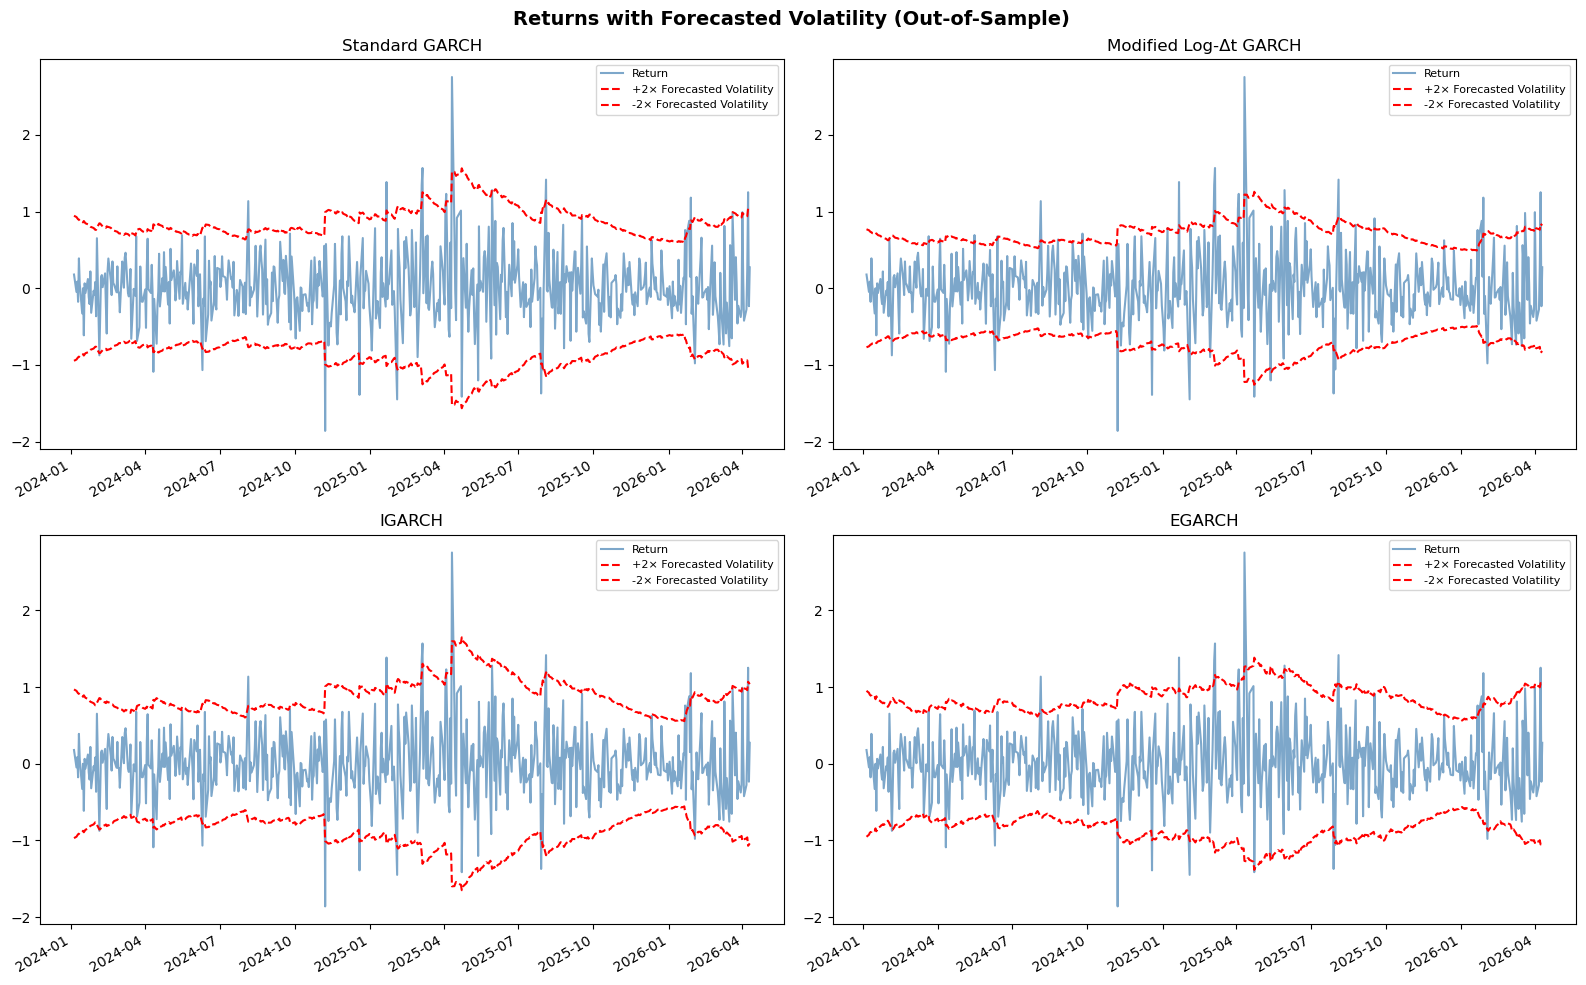

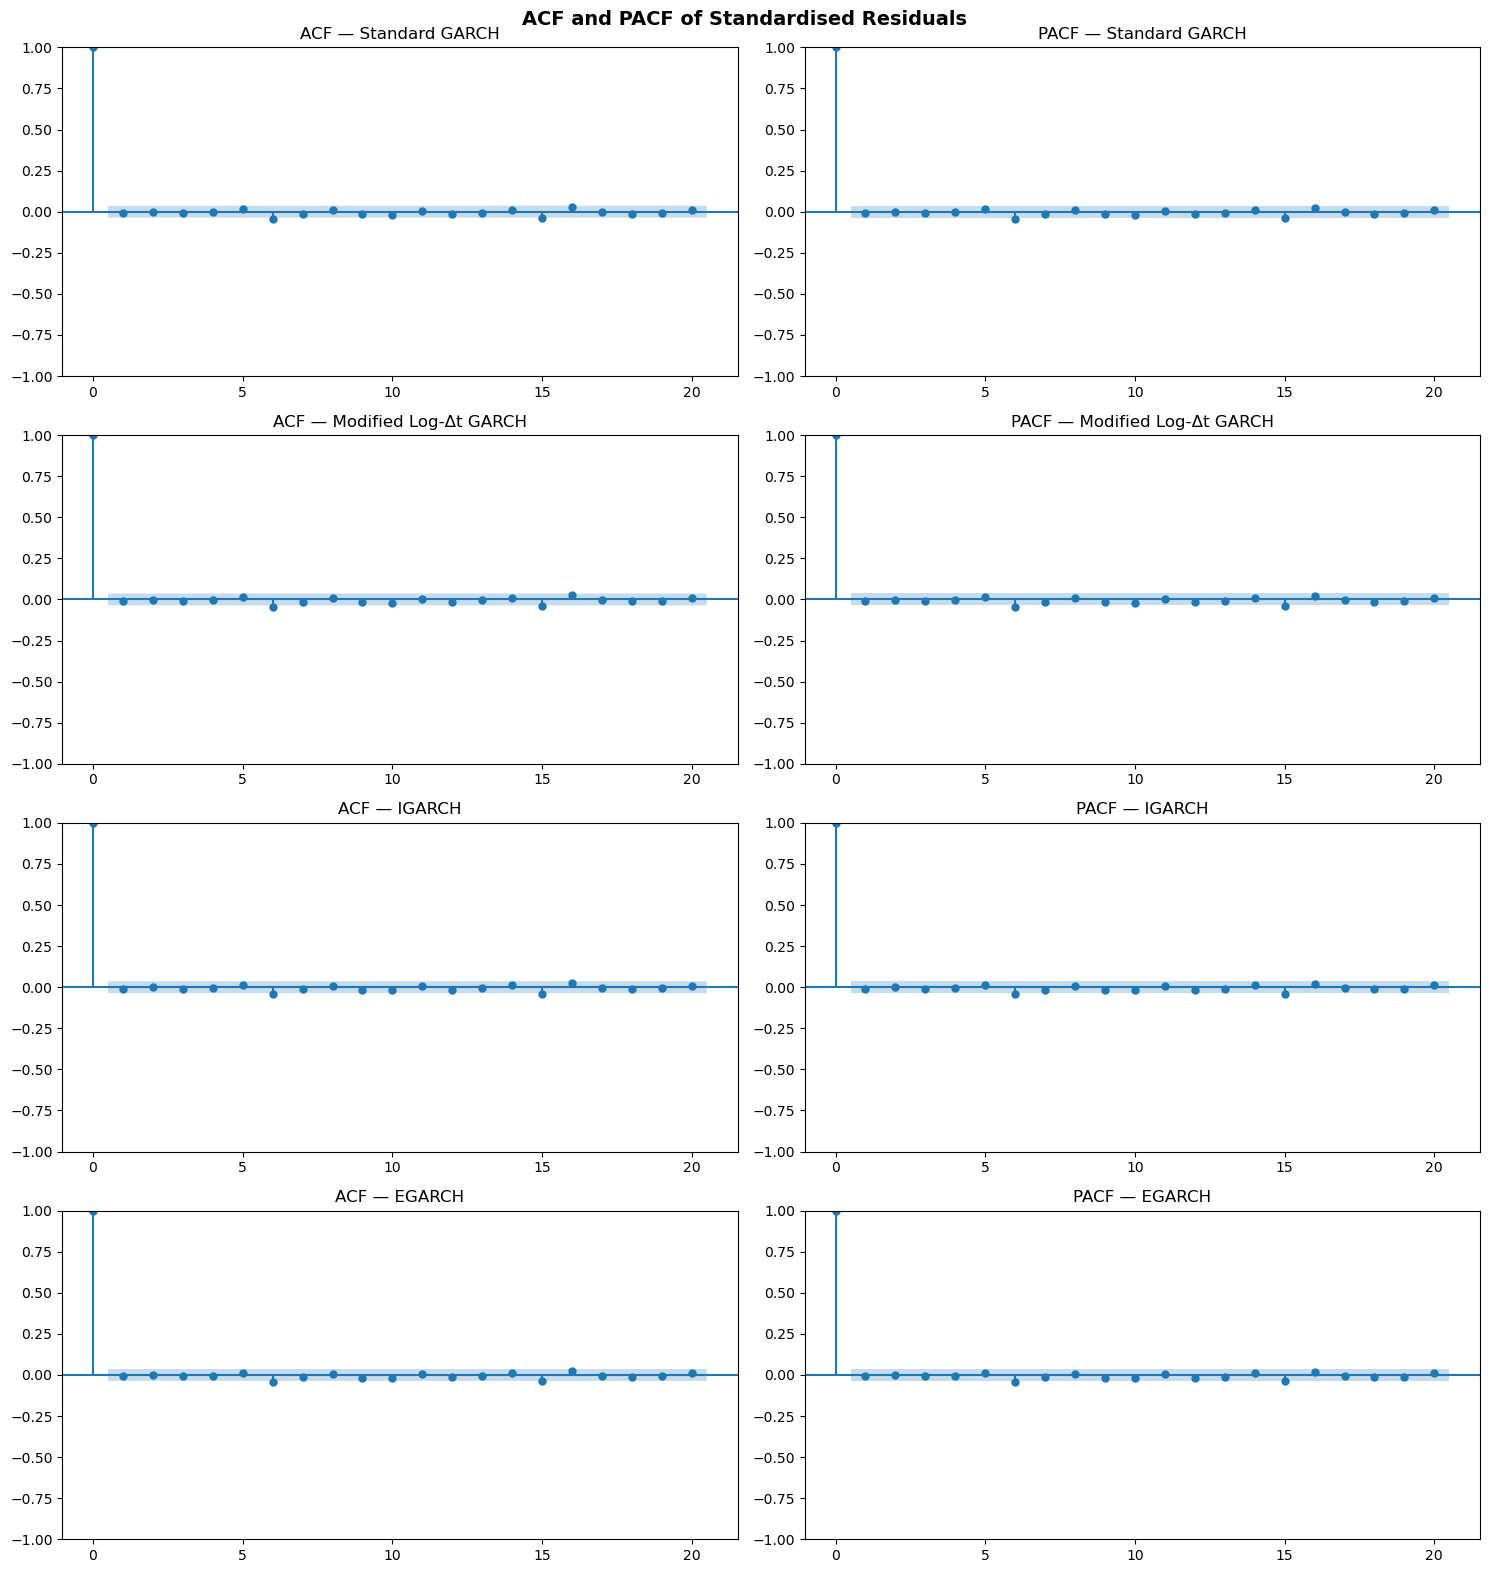

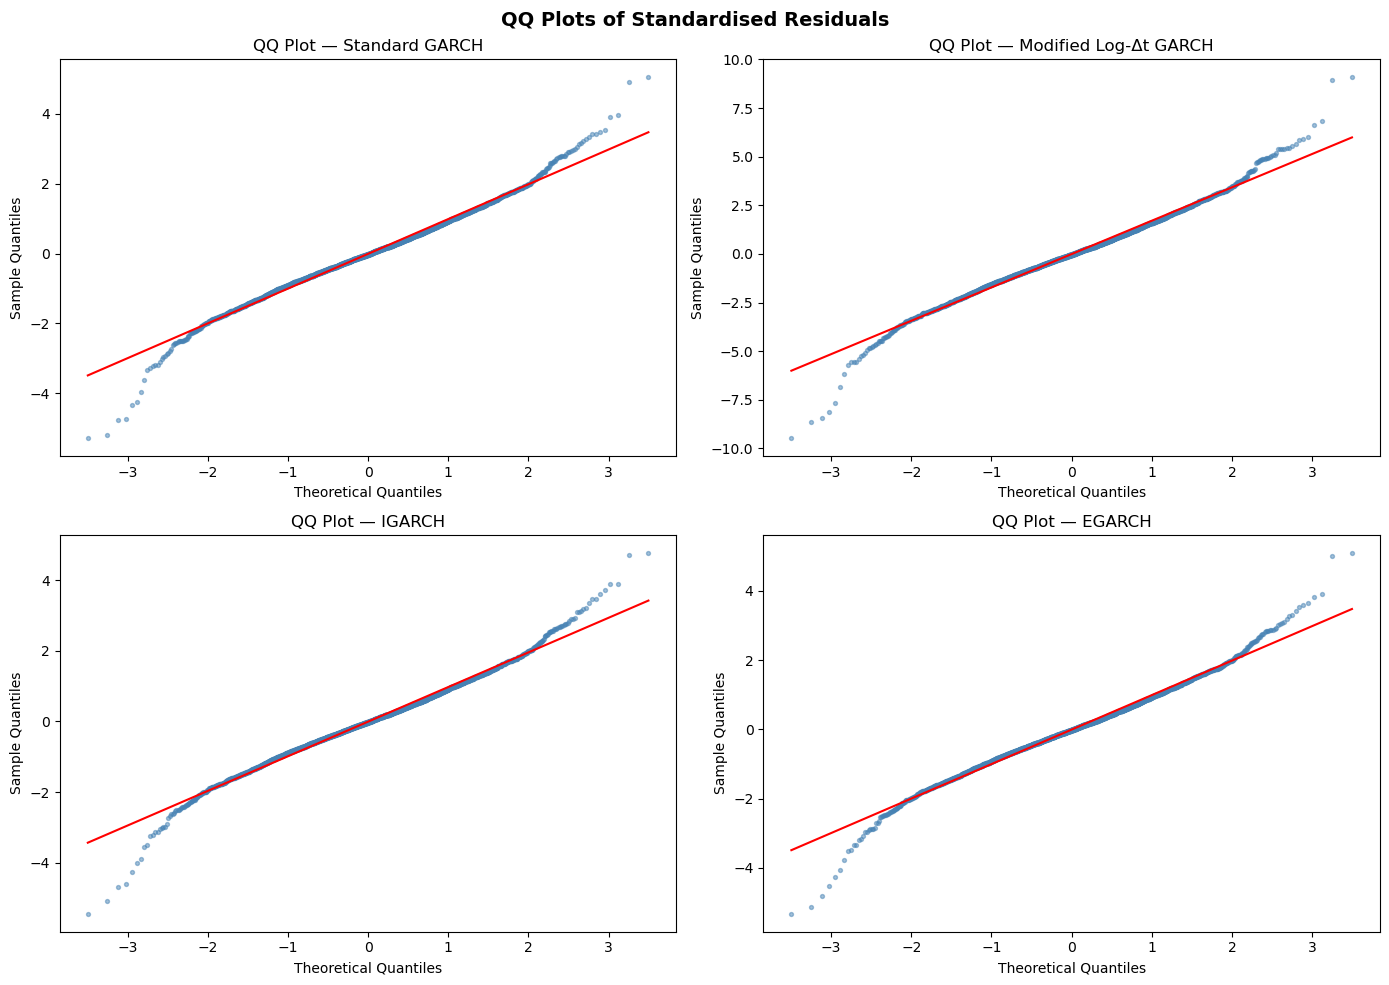


FULL DIAGNOSTIC SUMMARY

3-STEP FORECAST:

 Horizon  Std GARCH σ²  Modified Log-Δt σ²  IGARCH σ²  EGARCH σ²
       1    0.23074812          0.15238181 0.24333788 0.23630976
       2    0.23089527          0.15244913 0.24404874 0.23690945
       3    0.23104136          0.15251597 0.24475960 0.23750550

LOSS FUNCTIONS:

                Model        MSE        MAE                 MSRE       QLIKE
       Standard GARCH 0.19623445 0.20875798 9.50747611481677e+11 -0.80420007
Modified Log-Δt GARCH 0.20521929 0.18486033 4.22095053446137e+11 -0.76725317
               IGARCH 0.19566065 0.21226654 9.74158992917654e+11 -0.80729497
               EGARCH 0.20093362 0.20541677 9.48973732396869e+11 -0.78664261

VaR BACKTEST (95%):

                Model  Violations  Violation Rate  Expected Rate  Kupiec Stat  Kupiec p-value Model OK?
       Standard GARCH          20          0.0341           0.05       3.4803          0.0621       Yes
Modified Log-Δt GARCH          35          0.0597           0.0

In [311]:
# PART 5 — PLOTS & FINAL SUMMARY
import os
os.makedirs("plots", exist_ok=True)

# 1. FORECASTED VOLATILITY WITH RETURNS
#    (2 UP, 2 DOWN)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, name, pred in zip(
    axes,
    model_names,
    [y_test_std, y_test_mod, y_test_igarch, y_test_egarch]
):

    vol = pd.Series(
        np.sqrt(np.maximum(pred.values, 1e-8)),
        index=test_index
    )

    test_returns.plot(
        ax=ax,
        label="Return",
        color="steelblue",
        alpha=0.7
    )

    (2 * vol).plot(
        ax=ax,
        color="red",
        linestyle="--",
        label="+2× Forecasted Volatility"
    )

    (-2 * vol).plot(
        ax=ax,
        color="red",
        linestyle="--",
        label="-2× Forecasted Volatility"
    )

    ax.set_title(f"{name}")
    ax.legend(fontsize=8)
    ax.set_xlabel("")

fig.suptitle(
    "Returns with Forecasted Volatility (Out-of-Sample)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "plots/forecasted_volatility_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 2. ACF / PACF OF STANDARDISED RESIDUALS
#    (ALL IN ONE PICTURE)

fig, axes = plt.subplots(4, 2, figsize=(15, 16))

for i, (name, z) in enumerate(zip(model_names, resid_list)):

    plot_acf(
        z,
        lags=20,
        ax=axes[i, 0],
        title=f"ACF — {name}"
    )

    plot_pacf(
        z,
        lags=20,
        ax=axes[i, 1],
        title=f"PACF — {name}",
        method="ywm"
    )

fig.suptitle(
    "ACF and PACF of Standardised Residuals",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "plots/acf_pacf_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 3. QQ PLOTS
#    (2 UP, 2 DOWN)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, z) in enumerate(zip(model_names, resid_list)):

    (osm, osr), (slope, intercept, _) = stats.probplot(
        z,
        dist="norm"
    )

    osm_arr = np.array(osm)

    axes[i].scatter(
        osm_arr,
        osr,
        s=8,
        alpha=0.5,
        color="steelblue"
    )

    axes[i].plot(
        osm_arr,
        slope * osm_arr + intercept,
        color="red",
        linewidth=1.5
    )

    axes[i].set_title(f"QQ Plot — {name}")

    axes[i].set_xlabel("Theoretical Quantiles")

    axes[i].set_ylabel("Sample Quantiles")

fig.suptitle(
    "QQ Plots of Standardised Residuals",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "plots/qqplots_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# FINAL SUMMARY

print("\n" + "=" * 60)
print("FULL DIAGNOSTIC SUMMARY")
print("=" * 60)

print("\n3-STEP FORECAST:\n")
print(forecast_df.to_string(index=False))

print("\nLOSS FUNCTIONS:\n")
print(loss_df.to_string(index=False))

print("\nVaR BACKTEST (95%):\n")
print(var_df_95.to_string(index=False))

print("\nVaR BACKTEST (99%):\n")
print(var_df_99.to_string(index=False))

print("\nDIEBOLD-MARIANO:\n")
print(dm_df.to_string(index=False))

print("\nARCH-LM:\n")
print(arch_df.to_string(index=False))

print("\nJARQUE-BERA:\n")
print(jb_df.to_string(index=False))

print("\nLJUNG-BOX:\n")
print(lb_df.to_string(index=False))